# 04 — Model 1: Linear Baseline (raw logistic regression) on Sleep-EDF

**The bottom rung of the complexity ladder.** This is deliberately the *simplest possible* model:
**multinomial logistic regression on the raw, flattened 30-s epoch** — 3000 samples in, 5 sleep-stage
classes out, with **no feature engineering** at all. It is the low-complexity rung of the ladder, kept
deliberately **feature-free**: we want the honest floor of what a linear model can do reading the raw
signal, and — as the simplest, most directly-inspectable model — it doubles as an interpretability anchor
for validating the XAI/faithfulness machinery on a model whose parameters can be read directly.

**What this stage does — and only this.** Train the baseline and answer one question: *did it actually
learn, or does it just predict the majority class?* No XAI, no faithfulness harness, no other models.

**Design choices (kept deliberately weak and honest):**
- **No feature engineering** — the model sees the raw 3000-sample epoch.
- **No class weighting, no resampling** — consistent with the Phase-2 no-rebalancing decision. Sleep-EDF
  is imbalanced (N3 ~6.7%), and we want to *see* the baseline struggle on minorities rather than paper
  over it. This is the honest weak baseline.
- **L2 regularisation** — 3000 features on imbalanced data would overfit unregularised, so we keep
  scikit-learn's default L2 penalty (`C = 1.0`) on standardised inputs. Noted on the record.
- **Multi-seed from the start** — single-seed results can mislead, so we run multiple seeds to establish
  that findings are robust to initialisation rather than artefacts of one run. Note in advance:
  logistic regression is a *convex* problem, so a deterministic solver returns the *same* fit regardless
  of seed — we still run 5 seeds to confirm this empirically and keep the protocol uniform across the
  ladder. The *informative* seed-variance comparison begins with the neural models.

**What we report:** overall + balanced accuracy (per seed and averaged), the explicit majority-class
floor, per-class precision/recall/F1, a confusion matrix, and seed-to-seed variance — then a plain
verdict: learned-something vs degenerate.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]          # notebooks/sleep_edf/ -> repo root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, classification_report)

from sleep_edf.loader import load_sleep_edf          # Stage-3 cached, validated loader
import sleep_edf.config as cfg                      # Stage-5 config (3000 / 1 / 5)

CLASS_NAMES = ["W", "N1", "N2", "N3", "REM"]
SEEDS = [0, 1, 2, 3, 4]
C_L2 = 1.0            # inverse L2 strength (sklearn default); noted in the log

FIG_DIR = PROJECT_ROOT / "sleep_edf" / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=3, suppress=True)
print("config:", f"INPUT_LENGTH={cfg.INPUT_LENGTH}", f"IN_CHANNELS={cfg.IN_CHANNELS}",
      f"N_CLASSES={cfg.N_CLASSES}")


config: INPUT_LENGTH=3000 IN_CHANNELS=1 N_CLASSES=5


## 1. Load the data and look the imbalance in the eye

We load the cached train/test arrays (per-epoch z-normalised EEG Fpz-Cz, labels 0–4) and print the
class balance for both splits **before** training, so the imbalance is explicit going in. We also
compute the **majority-class floor** — the accuracy you get for free by always predicting the single
largest class. Any model scoring near that floor has not learned anything useful; it is just betting on
the most common stage.


In [2]:
X_train, y_train = load_sleep_edf("train")
X_test,  y_test  = load_sleep_edf("test")

# Contract checks (cheap, loud if wrong).
assert X_train.shape[1] == cfg.INPUT_LENGTH and X_test.shape[1] == cfg.INPUT_LENGTH
assert set(np.unique(y_train)) <= set(range(cfg.N_CLASSES))
print("X_train:", X_train.shape, X_train.dtype, "| X_test:", X_test.shape)
print("y range:", int(y_train.min()), "..", int(y_train.max()), "| dtype", y_train.dtype)
print()

print(f"{'stage':<6}{'train n':>10}{'train %':>9}{'test n':>10}{'test %':>9}")
print("-" * 44)
for c in range(cfg.N_CLASSES):
    ntr, nte = int((y_train == c).sum()), int((y_test == c).sum())
    print(f"{CLASS_NAMES[c]:<6}{ntr:>10}{100*ntr/len(y_train):>8.1f}%{nte:>10}{100*nte/len(y_test):>8.1f}%")

# Majority-class floor on the TEST set = proportion of the single largest test class.
test_counts = np.bincount(y_test, minlength=cfg.N_CLASSES)
floor_cls = int(test_counts.argmax())
floor = test_counts[floor_cls] / len(y_test)
chance_balanced = 1.0 / cfg.N_CLASSES
print("-" * 44)
print(f"majority-class floor (always predict {CLASS_NAMES[floor_cls]}): {floor:.4f} "
      f"({100*floor:.1f}% of test)")
print(f"balanced-accuracy chance level (5 classes): {chance_balanced:.4f}")


X_train: (155334, 3000) float32 | X_test: (40145, 3000)
y range: 0 .. 4 | dtype int64

stage    train n  train %    test n   test %
--------------------------------------------
W          52984    34.1%     12967    32.3%
N1         16971    10.9%      4551    11.3%
N2         54453    35.1%     14679    36.6%
N3         10323     6.6%      2716     6.8%
REM        20603    13.3%      5232    13.0%
--------------------------------------------
majority-class floor (always predict N2): 0.3656 (36.6% of test)
balanced-accuracy chance level (5 classes): 0.2000


**Note on the floor.** The single largest class *in the test split* is **N2 (~36.6%)**, so the
majority-class floor is ~0.366 — slightly higher than wake (~32% in this split; wake is ~34% of the
*whole* dataset before the subject split reshuffles proportions). We compare accuracy against this
0.366 floor, and balanced accuracy against the 5-class chance level of 0.20.


## 2. Train the linear baseline, 5 seeds

Each "model" is: **standardise the 3000 raw features** (StandardScaler, fit on train only — no test
statistics leak), then **multinomial logistic regression** with L2 (`C=1.0`, `solver='lbfgs'`, which
optimises the softmax/multinomial loss). We standardise once (it does not depend on the model seed) and
refit the classifier under each seed.

Because the multinomial-logistic objective is **convex** and `lbfgs` is **deterministic**, `random_state`
cannot move the solution — we expect the 5 seeds to be *identical*. That is the correct, honest answer to
"do the seeds agree?" for a linear model, and a useful contrast to the neural rungs (where seeds *will*
matter). The **parameter count** (5 classes × 3000 features + 5 biases = 15 005) is recorded as the
ladder's low point.


In [3]:
# Standardise once (seed-independent); fit on train only.
scaler = StandardScaler().fit(X_train)
Xtr = scaler.transform(X_train).astype(np.float32)
Xte = scaler.transform(X_test).astype(np.float32)

rows, first_model = [], None
for seed in SEEDS:
    clf = LogisticRegression(C=C_L2, penalty="l2", solver="lbfgs",
                             max_iter=200, random_state=seed, n_jobs=-1)
    clf.fit(Xtr, y_train)
    yp = clf.predict(Xte)
    rows.append(dict(
        seed=seed,
        acc=accuracy_score(y_test, yp),
        bacc=balanced_accuracy_score(y_test, yp),
        macro_f1=f1_score(y_test, yp, average="macro"),
        converged=int(clf.n_iter_[0]) < 200,
    ))
    if first_model is None:
        first_model, first_pred = clf, yp

n_params = first_model.coef_.size + first_model.intercept_.size
print(f"parameter count (Model 1, ladder low point): {n_params:,} "
      f"(= {first_model.coef_.shape[0]}×{first_model.coef_.shape[1]} weights + "
      f"{first_model.intercept_.size} biases)\n")

print(f"{'seed':<6}{'accuracy':>10}{'bal.acc':>10}{'macro-F1':>10}{'converged':>11}")
print("-" * 47)
for r in rows:
    print(f"{r['seed']:<6}{r['acc']:>10.4f}{r['bacc']:>10.4f}{r['macro_f1']:>10.4f}{str(bool(r['converged'])):>11}")

acc_m  = np.mean([r['acc'] for r in rows]);  acc_s  = np.std([r['acc'] for r in rows])
bacc_m = np.mean([r['bacc'] for r in rows]); bacc_s = np.std([r['bacc'] for r in rows])
print("-" * 47)
print(f"{'mean':<6}{acc_m:>10.4f}{bacc_m:>10.4f}{np.mean([r['macro_f1'] for r in rows]):>10.4f}")
print(f"{'std':<6}{acc_s:>10.6f}{bacc_s:>10.6f}{np.std([r['macro_f1'] for r in rows]):>10.6f}")


parameter count (Model 1, ladder low point): 15,005 (= 5×3000 weights + 5 biases)

seed    accuracy   bal.acc  macro-F1  converged
-----------------------------------------------
0         0.3799    0.2258    0.1971       True
1         0.3799    0.2258    0.1971       True
2         0.3799    0.2258    0.1971       True
3         0.3799    0.2258    0.1971       True
4         0.3799    0.2258    0.1971       True
-----------------------------------------------
mean      0.3799    0.2258    0.1971
std     0.000000  0.000000  0.000000


## 3. Did it learn? — accuracy vs the floor, and seed variance

Read the numbers against two reference lines: the **majority floor (0.366)** for accuracy, and **chance
(0.20)** for balanced accuracy. The seed **std** tells us whether the 5 runs agree.


In [4]:
print(f"accuracy      : {acc_m:.4f}   (floor {floor:.4f};  margin {acc_m - floor:+.4f})")
print(f"balanced acc  : {bacc_m:.4f}   (chance {chance_balanced:.4f};  margin {bacc_m - chance_balanced:+.4f})")
print(f"seed std      : accuracy {acc_s:.6f},  balanced-acc {bacc_s:.6f}")
print()
if acc_s < 1e-6:
    print("seed variance is ~0: as expected, the convex logistic fit is identical across seeds")
    print("(random_state has no effect on a deterministic lbfgs solve).")


accuracy      : 0.3799   (floor 0.3656;  margin +0.0143)
balanced acc  : 0.2258   (chance 0.2000;  margin +0.0258)
seed std      : accuracy 0.000000,  balanced-acc 0.000000

seed variance is ~0: as expected, the convex logistic fit is identical across seeds
(random_state has no effect on a deterministic lbfgs solve).


## 4. Per-class performance — where it fails

Overall accuracy hides *which* stages the model handles. The stage was explicitly commissioned to expose
the **minority classes N1 (~11%) and N3 (~6.7%)**, which a weak baseline is expected to handle poorly.
Below: per-class precision/recall/F1, the confusion matrix, and the model's **predicted-class
distribution** (which classes it ever actually predicts). All seeds are identical, so we use seed 0.


In [5]:
print(classification_report(y_test, first_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
pred_counts = np.bincount(first_pred, minlength=cfg.N_CLASSES)
print("predicted-class distribution (how often the model predicts each stage):")
for c in range(cfg.N_CLASSES):
    print(f"  {CLASS_NAMES[c]:<4}{pred_counts[c]:>7}  ({100*pred_counts[c]/len(first_pred):>4.1f}% of predictions)")
never = [CLASS_NAMES[c] for c in range(cfg.N_CLASSES) if pred_counts[c] < 0.01 * len(first_pred)]
print(f"\nstages the model almost never predicts (<1% of outputs): {never or 'none'}")


              precision    recall  f1-score   support

           W      0.375     0.480     0.421     12967
          N1      0.240     0.025     0.045      4551
          N2      0.393     0.598     0.474     14679
          N3      0.000     0.000     0.000      2716
         REM      0.197     0.026     0.046      5232

    accuracy                          0.380     40145
   macro avg      0.241     0.226     0.197     40145
weighted avg      0.317     0.380     0.320     40145

predicted-class distribution (how often the model predicts each stage):
  W     16615  (41.4% of predictions)
  N1      467  ( 1.2% of predictions)
  N2    22357  (55.7% of predictions)
  N3       10  ( 0.0% of predictions)
  REM     696  ( 1.7% of predictions)

stages the model almost never predicts (<1% of outputs): ['N3']


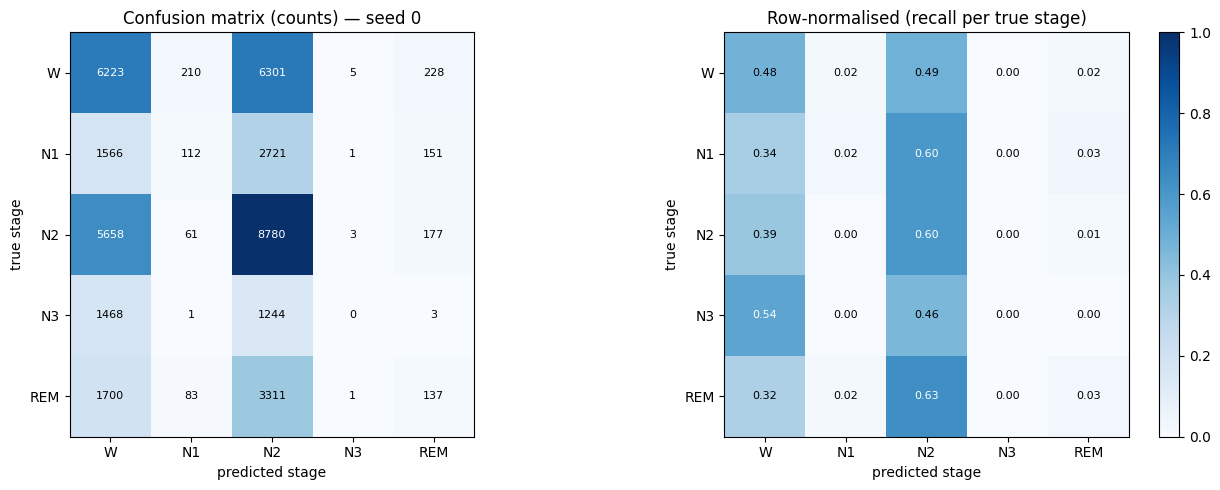

saved: results/sleep_edf/figures/sleep_edf_04_model1_confusion.png


In [6]:
cm = confusion_matrix(y_test, first_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)   # row-normalised = per-true-class recall spread

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

im0 = ax[0].imshow(cm, cmap="Blues")
ax[0].set_title("Confusion matrix (counts) — seed 0")
for i in range(5):
    for j in range(5):
        ax[0].text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() * 0.5 else "black", fontsize=8)

im1 = ax[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax[1].set_title("Row-normalised (recall per true stage)")
for i in range(5):
    for j in range(5):
        ax[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                   color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=8)

for a in ax:
    a.set_xticks(range(5)); a.set_xticklabels(CLASS_NAMES)
    a.set_yticks(range(5)); a.set_yticklabels(CLASS_NAMES)
    a.set_xlabel("predicted stage"); a.set_ylabel("true stage")
fig.colorbar(im1, ax=ax[1], fraction=0.046)
fig.tight_layout()
fig.savefig(FIG_DIR / "sleep_edf_04_model1_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved:", (FIG_DIR / "sleep_edf_04_model1_confusion.png").relative_to(PROJECT_ROOT))


## 5. Verdict — weak-but-not-degenerate

**What the numbers say.**
- **Accuracy 0.380 vs the 0.366 majority floor** — only **~1.4 points** above always-predicting-N2.
- **Balanced accuracy 0.226 vs 0.20 chance** — **~2.6 points** above random, so it is *not* purely
  betting on one class.
- **It uses two classes, not one.** The model predicts almost exclusively **W and N2** (the two largest
  stages) and gets moderate recall there (W ≈ 0.48, N2 ≈ 0.60). So it is *not* a single-class degenerate
  predictor — it has learned a coarse "big-slow-wake vs light-sleep" style split.
- **It is effectively blind to the minorities.** **N3 recall = 0.00** (predicted ~10 times in 40k), **N1
  recall ≈ 0.03, REM recall ≈ 0.03**. Exactly the failure the stage was set up to expose: a raw linear
  model cannot separate N1/N3/REM from the two dominant stages.
- **Zero seed variance** — the convex fit is identical across all 5 seeds, as expected for a linear model.

**Plain verdict: the baseline learned *something*, but only just.** It is **weak-but-not-degenerate** —
above both the majority floor (accuracy) and chance (balanced accuracy), and it genuinely uses two
classes rather than collapsing to one, but it is essentially a W-vs-N2 discriminator that ignores N1,
N3, and REM. This is an **acceptable bottom rung**: a real (if poor) signal to attribute later, not a
pure majority-class predictor. The scarce-class blindness (especially N3) is worth carrying forward as a
caveat for any per-class faithfulness we compute on this model.

*Nothing was applied beyond training and evaluation — no XAI, no faithfulness harness, no other model,
and nothing saved to disk except this notebook and the confusion-matrix figure.*
